# Shift and sum PRN correlated voltages

- Load the preprocessed data
- Load the verified acquired satellites and their carrier doppler values
- Corralate the pre-processed voltages with PRN filters from acquired satellites
- Roll off the carrier doppler
- Shift the PRN correlation streams by inter-TART geometric delays
- Correlate the shifted PRN-correlation streams, hopefully revealing a small systematic time delay between TART sites

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import json
# Get parent directory
parent_dir = os.path.abspath("..")
# Add it to sys.path
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from pipeline.JSON_handler import load_from_json, to_json_safe, save_to_json
from pipeline.dataloader import raw_data_loader
from pipeline.acquisition_handler import acquire_GPS 
from pipeline.geometric_delay import geometry
from pipeline.signalprocessing import signal_processing_handler

In [3]:
TARTS = {
    'namibia': 'na-unam',
    'rhodes': 'za-rhodes'
}

DATASETS = {
    'rhodes': 'rhodes/data_2026-02-13_14_39_25.231047.hdf',
    'namibia': 'namibia/data_2026-02-13_14_39_25.193869.hdf'
}

t_obs = 1770993565.3405828

obs_filepath = f"/home/jdawson/repos/TART/notebooks/dataproducts/{t_obs}"
meta_filepath = f"/home/jdawson/repos/TART/datasets/GPS"

viable_satellites_filename = "GPS_viable_satellites.json"
viable_satellites = load_from_json(obs_filepath, viable_satellites_filename)

acquisition_results_filename = 'GPS_acquisition_results.json'
acquisition_results = load_from_json(obs_filepath, acquisition_results_filename)

geometric_delays_filename = "inter_TART_geometric_delays.json"
geometric_delays = load_from_json(obs_filepath, geometric_delays_filename)

## Load the preprocessed data

In [4]:
loader = raw_data_loader("/home/jdawson/repos/TART/datasets")
data_rhodes, time_rhodes, Fs_rhodes = loader.load_preprocessed_data(DATASETS['rhodes'])
data_namibia, time_namibia, Fs_namibia = loader.load_preprocessed_data(DATASETS['namibia'])
Fs_baseband = data_rhodes['Fs']
print(f"Each antenna stream has length: {data_rhodes['data'][0].shape}")

Loading: rhodes/data_2026-02-13_14_39_25.231047.hdf...
Completed.
Loading: namibia/data_2026-02-13_14_39_25.193869.hdf...
Completed.
Each antenna stream has length: (4194300,)


## Combine the data into a single dictionary

In [5]:
TART_DATA = {
    'rhodes': {
        'data': data_rhodes['data'],
    },
    'namibia': {
        'data': data_namibia['data'],
    }
}

## Generate the PRN code filters

In [6]:
acquisition_handler = acquire_GPS(Fs=Fs_baseband)
prn_codes = acquisition_handler.generate_all_prn_codes()
print(f"PRN code filters created with shape: ({len(prn_codes)},{prn_codes[1].shape[0]}). Aka: 1ms (=1 PRN period cycle) of chip values.")

Pre-computing PRN codes for all satellites...
Done.
PRN code filters created with shape: (32,16368). Aka: 1ms (=1 PRN period cycle) of chip values.


## Choose the reference antennas to use from each site for each satellite

In [7]:
ref_antennas = {
    "G23": {
        "rhodes": 8,
        "namibia": 2,
    },
    "G28": {
        "rhodes": 2,
        "namibia": 8,
    },
    "G31": {
        "rhodes": 8,
        "namibia": 1,
    }
}

## Correlate and shift the PRN filters with (carrier) doppler corrected antenna streams

In [8]:
signal_handler = signal_processing_handler()

In [9]:
# Instantiate a dictionary ready to populate with shifted correlations

shifted_correlations = {'rhodes':{},
                       'namibia':{}}

In [11]:
for satellite in ref_antennas:
    for TART in TARTS:
        # Gererate the PRN correlation streams
        antenna_correlation = signal_handler.get_correlations(TART, TART_DATA, Fs_baseband, acquisition_results, ref_antennas, satellite, prn_codes)
        if TART == 'rhodes':
            # Rhodes is the reference antenna so don't shift it, simply concatenate it
            shifted_correlations[TART][satellite] = antenna_correlation
            continue
        # If not the reference TART, then apply the required inter-TART geometric delay shift to the correlation streams
        shifted_signal = signal_handler.apply_delay(antenna_correlation, geometric_delays[satellite][TART], Fs_baseband)
        shifted_correlations[TART][satellite] = shifted_signal

In [13]:
print("A reminder that the Namibia signals were just delayed by the following geometric delay times: ")
geometric_delays

A reminder that the Namibia signals were just delayed by the following geometric delay times: 


{'G23': {'namibia': 0.002051478955840275},
 'G28': {'namibia': 0.001105966175862335},
 'G31': {'namibia': 0.003299716710206912}}

## Visualise the correlation streams having delayed to the reference TART

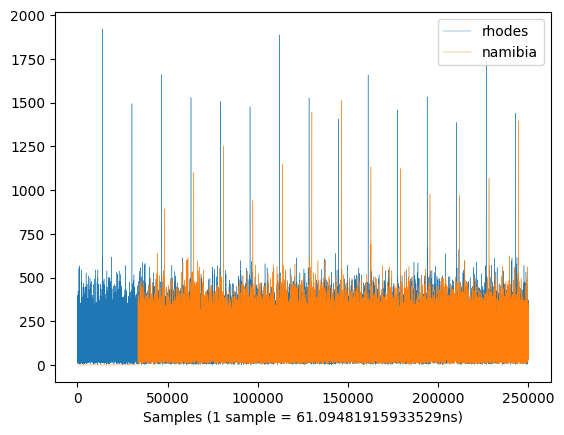

In [29]:
plt.figure()
plt.plot(shifted_correlations['rhodes']['G23'][:250000], linewidth=0.3, label='rhodes')
plt.plot(shifted_correlations['namibia']['G23'][:250000], linewidth=0.3, label='namibia')
plt.xlabel(f'Samples (1 sample = {1e9/Fs_baseband}ns)') 
legend = plt.legend()

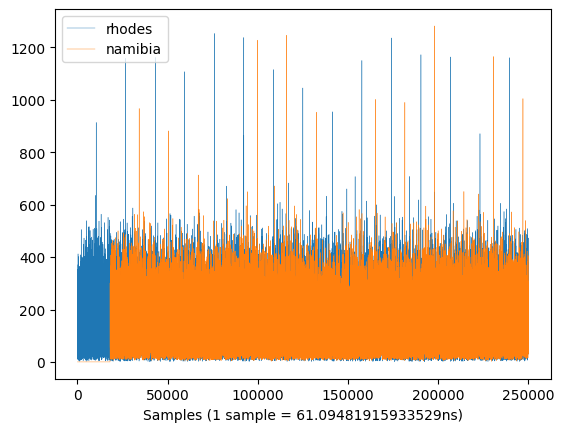

In [30]:
plt.figure()
plt.plot(shifted_correlations['rhodes']['G28'][:250000], linewidth=0.3, label='rhodes')
plt.plot(shifted_correlations['namibia']['G28'][:250000], linewidth=0.3, label='namibia')
plt.xlabel(f'Samples (1 sample = {1e9/Fs_baseband}ns)') 
legend = plt.legend()

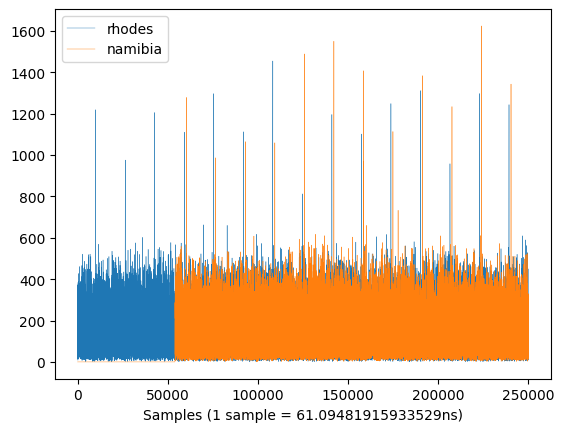

In [31]:
plt.figure()
plt.plot(shifted_correlations['rhodes']['G31'][:250000], linewidth=0.3, label='rhodes')
plt.plot(shifted_correlations['namibia']['G31'][:250000], linewidth=0.3, label='namibia')
plt.xlabel(f'Samples (1 sample = {1e9/Fs_baseband}ns)') 
legend = plt.legend()